# Fall 2025 - Assignment 1
### Students Name and ID:
- Haonan Feng - 11329202
- Navid Namazi Baigi - 11353323

Electronic submission on ZoneCours no later than **October 17 at 11:55 PM** of:

* This Jupyter notebook (.ipynb) as the report, after adding your answers.
* All .py files necessary to run the notebook

The report must:

* be in .ipynb format (points will be deducted for any other format).
* include the student ID number of all team members in the first cell (i.e., replace these instructions).
* answer the questions and discuss the results using tables, figures, and Markdown cells.

Grading rubric:

* **40%** Accuracy of results
* **25%** Complete and concise discussions (Markdown cells)
* **20%** Conciseness of the notebook (.ipynb with minimal code) and clarity of figures
* **15%** Code clarity (.py)

# Context

We are going to consider the most liquid options traded on Apple on two particular business days of 2020: January 17 and March 20. The next couple of code cells were used to generate the dataset by connecting to OptionMetrics. With `GENERATE = False`, they simply load the dataset as saved to disk.

In [1]:
# The following import allow absolute imports scripts within the dorion_francois package
# import internal_script 

import datetime as dt
import os
import sys
import numpy as np
import pandas as pd
import pickle
import importlib
from helpers.data_check import df_summary

# Show all columns, do not truncate horizontally
pd.set_option('display.max_columns', None)
# Show all rows, do not truncate vertically
# pd.set_option('display.max_rows', None)

In [2]:
def filters(options):
    """These filters were applied to the data"""
    # Options before maturity
    options = options.loc[options.date < options.exdate].reset_index()

    # Positive open interest
    options = options[options['open_interest'] > 0] 

    # Abs(delta) between 0.01 and 0.99
    options = options[(options['delta'].abs() >= 0.01) & (options['delta'].abs() <= 0.99)] 

    # Implied vol between 0.03 and 2
    options = options[(options['impl_volatility'] >= 0.03) & (options['impl_volatility'] <= 2)] 

    # Bid price is greater than 0.1 and less than ask price
    options = options[(options['best_offer'] > options['best_bid']) & (options['best_bid'] > 0.1)] 
    
    return options

GENERATE = False
if GENERATE:
    import dorion_francois.option_metrics as om    
    jan17 = om.get_option_data(101594, dt.date(2020,1,17))
    mar20 = om.get_option_data(101594, dt.date(2020,3,20))
    options = filters( pd.concat((jan17,mar20),axis=0) )
    with open('202510-assignment1.pkl','wb') as fh:
        # OptionMetrics 'strike_price' column is the strike x1000. We'll drop it to avoid confusion; use the 'strike' column
        pickle.dump(options.drop(columns=['strike_price']),fh)
else:
    with open('202510-assignment1.pkl','rb') as fh:
        options = pickle.load(fh)

options.reset_index(inplace=True)
display(options.describe())

,level_0,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,hash,strike,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
count,3041.000000,3041.000000,3041.0,3041.0,3041.0,3041.0,3041.0,3041.000000,3041.0,3041.0,3041.0,3041.0,3041.0,3041.0,3041.0,3041.0,3.041000e+03,3041.0,3041.0,3041.000000,3041.000000,3041.000000,3041.000000,3041.000000,3041.000000,3039.000000,2907.000000,3041.000000
mean,2204.334101,1290.575469,101594.0,39.54265,41.070812,302.719171,1493.480434,0.486984,0.051175,0.004216,43.996647,-34.136704,130415376.903321,1.0,0.0,100.0,9.101658e+18,271.62611,40.306731,247.602105,0.678362,0.011057,267.849300,266.408353,268.266957,0.491364,0.463369,0.517211
std,1180.259707,588.418749,0.0,47.505847,48.379765,1413.149222,2810.188475,0.246677,0.573104,0.00421,39.878651,42.649761,3187762.914267,0.0,0.0,0.0,5.314394e+18,89.964556,47.939597,256.838994,0.703668,0.005106,44.329611,44.126488,45.364910,0.240483,0.227888,0.264064
min,28.000000,166.000000,101594.0,0.11,0.14,0.0,1.0,0.209335,-0.989916,0.00004,0.264909,-329.0443,119448757.0,1.0,0.0,100.0,5.077881e+15,75.0,0.13,7.000000,0.019178,0.004597,229.240000,226.093746,227.456884,0.209760,0.004413,0.211192
25%,1205.000000,805.000000,101594.0,3.85,4.75,0.0,76.0,0.308580,-0.332122,0.001665,13.6014,-43.18185,130428991.0,1.0,0.0,100.0,4.510935e+18,205.0,4.25,35.000000,0.095890,0.006167,229.240000,227.603325,228.595023,0.313801,0.290405,0.324194
50%,2273.000000,1334.000000,101594.0,20.05,21.5,14.0,383.0,0.407585,0.02422,0.003027,29.80537,-17.72565,131685030.0,1.0,0.0,100.0,9.095769e+18,270.0,20.8,154.000000,0.421918,0.008564,229.240000,229.240000,229.774853,0.414581,0.389198,0.437239
75%,3271.000000,1800.000000,101594.0,60.75,63.0,97.0,1594.0,0.593389,0.526664,0.005168,64.20898,-9.199282,132338173.0,1.0,0.0,100.0,1.352230e+19,330.0,61.75,455.000000,1.246575,0.016588,318.730000,317.145554,319.221626,0.603811,0.573138,0.637671
max,4085.000000,2345.000000,101594.0,271.0,275.5,29443.0,28015.0,1.998797,0.989859,0.042843,193.543,2.572634,133176505.0,1.0,0.0,100.0,1.844408e+19,520.0,273.25,882.000000,2.416438,0.017424,318.730000,318.730000,325.069560,1.656574,1.601841,2.527934


# Looking At The Data

In [3]:
#split options on Jan 17, 2020 and Mar 20, 2020 into two dataframes
options1=options [options ['date']==dt.date(2020,1,17)].reindex()  #options on Jan 17, 2020
options2=options [options ['date']==dt.date(2020,3,20)].reindex()   #options on Mar 20, 2020
display(options1.head())
display(options2.head())

,level_0,index,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,ss_flag,forward_price,expiry_indicator,root,suffix,hash,strike,option_price,is_call,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
0,28,190,101594.0,2020-01-17,AAPL 200124C240000,1,2020-01-24,2020-01-17,C,78.6,79.1,2.0,22.0,0.914445,0.989751,0.00071,1.183559,-26.76116,131551967.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,812455354315213419,240.0,78.85,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.947993,NaN,1.074912
1,64,208,101594.0,2020-01-17,AAPL 200124C285000,1,2020-01-24,2020-01-17,C,33.7,33.9,44.0,2043.0,0.380190,0.985154,0.002416,1.628112,-15.05999,131551985.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,6442975529244062396,285.0,33.8,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.399629,0.332379,0.437975
2,66,209,101594.0,2020-01-17,AAPL 200124C287500,1,2020-01-24,2020-01-17,C,31.2,31.4,89.0,754.0,0.354379,0.984191,0.002736,1.71721,-14.81409,131551986.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,8977840135485698240,287.5,31.3,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.372518,0.308421,0.409034
3,68,210,101594.0,2020-01-17,AAPL 200124C290000,1,2020-01-24,2020-01-17,C,28.75,28.95,318.0,1531.0,0.351879,0.975943,0.003815,2.471972,-21.41726,131551987.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,8524937604001173348,290.0,28.85,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.364211,0.321515,0.394086
4,69,277,101594.0,2020-01-17,AAPL 200124P290000,1,2020-01-24,2020-01-17,P,0.12,0.14,2866.0,9733.0,0.344187,-0.022558,0.003532,2.363225,-21.30008,131552018.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,17541079441124028567,290.0,0.13,False,7,0.019178,0.015771,318.73,318.73,318.675355,0.344050,0.339721,0.348175


,level_0,index,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,ss_flag,forward_price,expiry_indicator,root,suffix,hash,strike,option_price,is_call,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
1312,1908,166,101594.0,2020-03-20,AAPL 200327C135000,1,2020-03-27,2020-03-20,C,93.15,96.4,1.0,56.0,1.998797,0.979937,0.000766,1.543098,-81.38992,132995045.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,2351176369942867699,135.0,94.775,True,7,0.019178,0.00745,229.24,229.24,229.699957,1.565938,NaN,2.527934
1313,1910,167,101594.0,2020-03-20,AAPL 200327C140000,1,2020-03-27,2020-03-13,C,88.25,91.05,0.0,11.0,1.793695,0.982596,0.000756,1.364458,-64.95656,132737814.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,6570680480884333529,140.0,89.65,True,7,0.019178,0.00745,229.24,229.24,229.699957,NaN,NaN,2.265144
1314,1911,247,101594.0,2020-03-20,AAPL 200327P140000,1,2020-03-27,2020-03-20,P,0.17,0.28,506.0,1312.0,1.651492,-0.011545,0.000577,0.960129,-41.32759,132737826.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,11812381253929513101,140.0,0.225,False,7,0.019178,0.00745,229.24,229.24,229.699957,1.656574,1.593775,1.709908
1315,1912,168,101594.0,2020-03-20,AAPL 200327C145000,1,2020-03-27,2020-03-17,C,83.3,86.05,0.0,38.0,1.697518,0.980642,0.000875,1.494512,-67.3017,132737815.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,15269956671680196482,145.0,84.675,True,7,0.019178,0.00745,229.24,229.24,229.699957,NaN,NaN,2.129291
1316,1913,248,101594.0,2020-03-20,AAPL 200327P145000,1,2020-03-27,2020-03-20,P,0.28,0.32,304.0,288.0,1.613269,-0.015266,0.000752,1.222757,-51.37753,132737827.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,10699880681992102797,145.0,0.3,False,7,0.019178,0.00745,229.24,229.24,229.699957,1.618606,1.601841,1.634672


In [4]:
#summary reports of options1 and options2
num_report1, non_num_report1 = df_summary(options1)
num_report2, non_num_report2 = df_summary(options2)
print("options on 2020,1,17 - Numerical columns Summary")
display(num_report1)
print("options on 2020,1,17 - Non-Numerical columns Summary")
display(non_num_report1)
print("options on 2020,3,20 - Numerical columns Summary")
display(num_report2)
print("options on 2020,3,20 - Non-Numerical columns Summary")
display(non_num_report2)

options on 2020,1,17 - Numerical columns Summary


,level_0,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,hash,strike,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
nan_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40,0
unique_count,1312,1312,1,896,904,382,901,1306,1312,1217,1312,1312,1312,1,1,1,1312,96,1110,16,16,16,1,9,16,1311,1272,1312
zero_count,0,0,0,0,0,320,0,0,0,0,0,0,0,0,1312,0,0,0,0,0,0,0,0,0,0,0,0,0
negative_count,0,0,0,0,0,0,0,0,614,0,0,1307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
min,28.0,190.0,101594.0,0.11,0.14,0.0,1.0,0.209335,-0.98457,0.000171,1.183559,-111.796,119448772.0,1.0,0.0,100.0,13250388696589696.0,110.0,0.13,7.0,0.019178,0.015771,318.73,314.852783,318.397407,0.20976,0.184678,0.211192
max,1902.0,2073.0,101594.0,197.15,201.25,29443.0,28015.0,0.914445,0.989859,0.042843,193.543,1.297433,132032992.0,1.0,0.0,100.0,18437254655043551232.0,520.0,199.175,882.0,2.416438,0.017424,318.73,318.73,325.06956,0.947993,0.541932,1.074912
mean,1027.757622,1197.373476,101594.0,33.962896,34.953216,392.5,1725.449695,0.311605,0.166316,0.005123,47.968484,-22.485545,130214527.278963,1.0,0.0,100.0,9301588776903690240.0,293.155488,34.458056,255.697409,0.700541,0.016753,318.73,317.039651,320.308706,0.317361,0.299826,0.330087
std,546.772013,548.487323,0.0,43.700025,44.531697,1860.557675,3128.533185,0.064687,0.560041,0.00567,47.316863,22.423878,2929377.294483,0.0,0.0,0.0,5372491535389096960.0,80.471052,44.113408,271.535115,0.743932,0.000495,0.0,1.204996,2.055714,0.070283,0.059376,0.080376
dtype,int64,int64,Float64,Float64,Float64,Float64,Float64,float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,uint64,Float64,Float64,int64,float64,float64,float64,float64,float64,float64,float64,float64


options on 2020,1,17 - Non-Numerical columns Summary


,date,symbol,symbol_flag,exdate,last_date,cp_flag,ss_flag,forward_price,expiry_indicator,root,suffix,is_call
nan_count,0,0,0,0,0,0,0,1312,914,1312,1312,0
unique_count,1,1312,1,16,31,2,1,0,1,0,0,2
empty_str_count,0,0,0,0,0,0,0,0,0,0,0,0
dtype,object,string[python],string[python],object,string[python],string[python],string[python],string[python],string[python],string[python],string[python],boolean
most_freq,2020-01-17,AAPL 200124C240000,1,2022-01-21,2020-01-17,C,0,None,w,None,None,True
most_freq_count,1312,1,1312,108,992,698,1312,0,398,0,0,698


options on 2020,3,20 - Numerical columns Summary


,level_0,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,hash,strike,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
nan_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,94,0
unique_count,1729,1729,1,1163,1221,418,1008,1726,1727,1523,1729,1729,1729,1,1,1,1729,106,1479,17,17,17,1,8,17,1723,1635,1729
zero_count,0,0,0,0,0,453,0,0,0,0,0,0,0,0,1729,0,0,0,0,0,0,0,0,0,0,0,0,0
negative_count,0,0,0,0,0,0,0,0,864,0,0,1711,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
min,1908.0,166.0,101594.0,0.12,0.18,0.0,1.0,0.232589,-0.989916,0.00004,0.264909,-329.0443,119448757.0,1.0,0.0,100.0,5077881350980829.0,75.0,0.16,7.0,0.019178,0.004597,229.24,226.093746,227.456884,0.341526,0.004413,0.367105
max,4085.0,2345.0,101594.0,271.0,275.5,16757.0,23485.0,1.998797,0.982596,0.013658,133.6303,2.572634,133176505.0,1.0,0.0,100.0,18444084649137674240.0,520.0,273.25,819.0,2.243836,0.008636,229.24,229.24,229.774931,1.656574,1.601841,2.527934
mean,3097.144014,1361.299017,101594.0,43.77668,45.712967,234.591671,1317.45749,0.620065,-0.036197,0.003528,40.982737,-42.977838,130567785.640833,1.0,0.0,100.0,8949946131303458816.0,255.289184,44.744824,241.459225,0.661532,0.006735,229.24,227.988305,228.776631,0.623555,0.590602,0.659205
std,612.550597,607.683865,0.0,49.798432,50.628347,936.031457,2528.940538,0.250602,0.567594,0.002387,32.834379,51.354929,3363480.100924,0.0,0.0,0.0,5266373584316467200.0,93.310755,50.210273,245.001504,0.671237,0.001531,0.0,1.047725,0.763007,0.239878,0.229345,0.26648
dtype,int64,int64,Float64,Float64,Float64,Float64,Float64,float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,uint64,Float64,Float64,int64,float64,float64,float64,float64,float64,float64,float64,float64


options on 2020,3,20 - Non-Numerical columns Summary


,date,symbol,symbol_flag,exdate,last_date,cp_flag,ss_flag,forward_price,expiry_indicator,root,suffix,is_call
nan_count,0,0,0,0,0,0,0,1729,1272,1729,1729,0
unique_count,1,1729,1,17,35,2,1,0,1,0,0,2
empty_str_count,0,0,0,0,0,0,0,0,0,0,0,0
dtype,object,string[python],string[python],object,string[python],string[python],string[python],string[python],string[python],string[python],string[python],boolean
most_freq,2020-03-20,AAPL 200327C135000,1,2021-01-15,2020-03-20,C,0,None,w,None,None,True
most_freq_count,1729,1,1729,130,1276,865,1729,0,457,0,0,865


# Question 1

Create a scatter plot with the risk-free rate (`100*options.risk_free`) against the time to maturity expressed in years (`options.YTM`). Discuss the figure. Given that the Black-Merton-Scholes economy assumes that the risk-free rate is constant, should one still account for the variation it illustrates if pricing options with the model? Why?

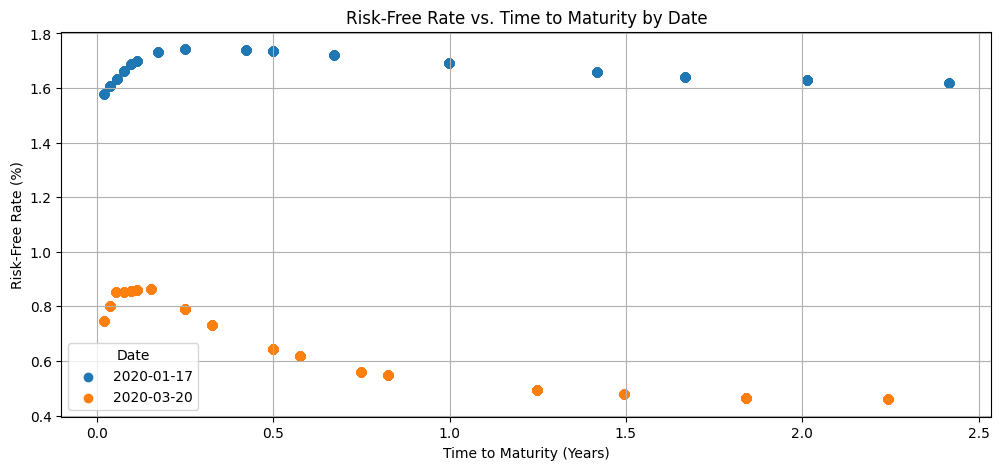

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))
plt.scatter(options1['YTM'], 100 * options1['risk_free'], color='tab:blue', label='2020-01-17')
plt.scatter(options2['YTM'], 100 * options2['risk_free'], color='tab:orange', label='2020-03-20')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Risk-Free Rate (%)')
plt.title('Risk-Free Rate vs. Time to Maturity by Date')
plt.legend(title='Date')
plt.grid(True)
plt.show()

**Discussion:**


- The scatter plot shows how the risk-free rate (annualized, in %) varies with the time to maturity for Apple options on two dates.
- Large differences between the two dates (blue and orange dots) reflect changes in monetary policy and market conditions, especially emergency rate cuts due to the COVID-19 pandemic on March 3 and March 15, 2020.
- The variation within each day based on time to maturity reflects the term structure of interest rates at that date (i.e., the yield curve).
-  In the Black–Merton–Scholes (BMS) framework, the risk-free rate $ r $ is assumed constant *through time for a given option*, but not necessarily identical across all maturities. Hence, when pricing each option, we can still use the risk-free rate corresponding to its own maturity to remain consistent with the observed yield curve.  

<hr style="border: none; border-top: 1px dashed gray;">

Although the BMS model assumes a constant risk-free rate over an option’s life, in practice $r$ can vary with maturity. If we assume $r$ evolves deterministically through time, the closed-form BSM solution remains valid with $r(t)$ integrated over the option’s life. However, If we assume $r$ as an stochastic function, we can not use BMS closed-form solution any more.

**Mathematical Support**

If we assume r is a deterministic function of time, the BSM formula can be modified as shown below, and the closed-form solution still exists.
$$
C = S_0 \, N(d_1) - K \, e^{-rT} N(d_2)
$$

where

$$
d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$

If r = r(t) is a deterministic function of time, the modified formula is:

$$
C = S_0 \, N(d_1) - K \, e^{-\int_0^T r(t)\,dt} N(d_2)
$$

where

$$
d_1 = \frac{\ln(S_0/K) + \left( \int_0^T r(t) dt + \frac{1}{2}\sigma^2 T \right)}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$


***
# Question 2
Similarly, scatter `options.stock - options.stock_exdiv`, where the former is the stock price and the latter accounts for the dividends **actually** paid over the life of the options.

Discuss the figure. Can we conclude that Apple changed its dividend policy between the two dates? Describe which variation of the Black-Merton-Scholes formula seen in class could be used to price the options on Apple if they were European options. Support your discussion with succinct mathematical expressions and/or derivations, in which you can focus on the calls without loss of generality.

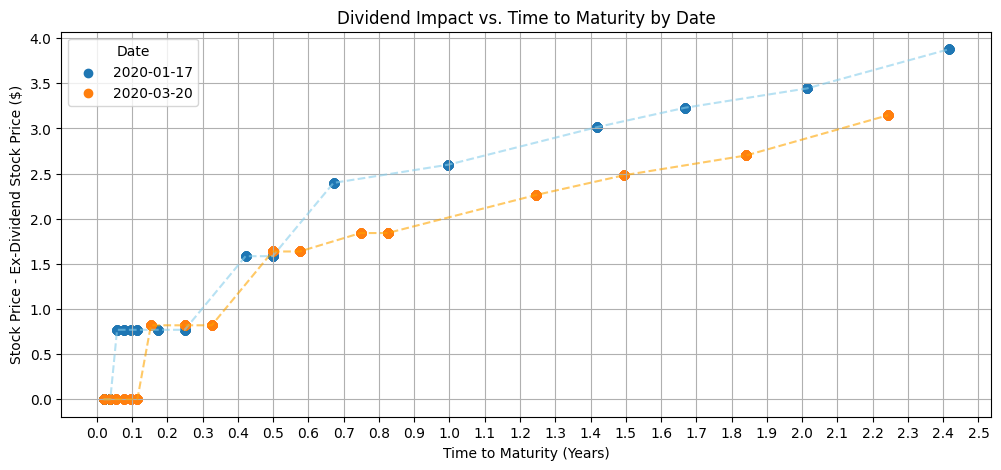

In [6]:
plt.figure(figsize=(12, 5))
plt.xticks(np.arange(0, max(options1['YTM'].max(), options2['YTM'].max()) + 0.1, 0.1))
plt.scatter(options1['YTM'], options1['stock_price'] - options1['stock_exdiv'], color='tab:blue', label='2020-01-17')
plt.scatter(options2['YTM'], options2['stock_price'] - options2['stock_exdiv'], color='tab:orange', label='2020-03-20')
plt.plot(options1['YTM'],options1['stock_price'] - options1['stock_exdiv'],color='skyblue',linestyle='--',alpha=0.6)
plt.plot(options2['YTM'],options2['stock_price'] - options2['stock_exdiv'],color='orange',linestyle='--',alpha=0.6)
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Stock Price - Ex-Dividend Stock Price ($)')
plt.title('Dividend Impact vs. Time to Maturity by Date')
plt.legend(title='Date')
plt.grid(True)
plt.show()

**Discussion:**
- **No! We can not conclude that Apple changed its dividend policy between the two dates**
- Both dates display increasing values as maturity extends, which is reasonable since longer-dated options accrue the present value of more future dividends( $I(t,T)$ increases with time to maturity).
- The level difference between the blue and orange dots at the same maturity does not indicate a change in dividend policy, because they represent options initiated two months apart and their life spans may capture a different range of dividend payments. Mathematically, they might have different dividends getting summed up in $\sum_{n=1}^{N} d(t_n)e^{-r(t_n - t)}$
- The overall pattern and slope are similar between January 17 2020 (blue) and March 20 2020 (orange), indicating that Apple’s dividend policy remained stable. If there were a meaningful change in policy,we would expect a separation or a shift in curve shape—this is not observed here.
- Finally, since the data reflect actual dividends paid rather than expected or announced dividends on the quoted dates, any change in Apple’s dividend policy during this short period would not be captured in the sample!

<hr style="border: none; border-top: 1px dashed gray;">


For European call options on a stock paying discrete dividends, the BMS formula adjusts for dividends as follows:

$$
c(t, T, K) = e^{-r(T-t)} \left[ F(t, T)\,\mathcal{N}(d_1) - K\,\mathcal{N}(d_2) \right]
$$

where

$$
d_1 = \frac{\ln \left( \frac{F(t,T)}{K} \right) + \frac{\sigma^2}{2}(T-t)}{\sigma \sqrt{T-t}}, \quad
d_2 = d_1 - \sigma \sqrt{T-t}
$$

and

$$
F(t, T) = e^{r(T-t)} \left( S(t) - \sum_{n=1}^N d(t_n) e^{-r(t_n-t)} \right ) = e^{r(T-t)} (S(t) - I(t, T))
$$



Here, $ \sum_{n=1}^{N} d(t_n)e^{-r(t_n - t)} $ represents the present value of all expected cash dividends paid before maturity, which are subtracted from the spot price.




***
# Question 3
Implement a function that inverts this variation of the BSM formula to obtain the BMS implied volatility for each of the options in the dataframe. Define moneyness as $M = K / \hat{S}_t$ and focus on out-of-the-money (OTM) options ($M \le 1$ puts, $M > 1$ calls). Create a dataframe `otm_options` containing only those options and add a column with the result of your IV calculation for each option therein.

In a 1x2 figure, scatter your results, with  on the x-axis, against a line plot for `implied_vol_bms`: In the left (right) panel, use options quoted on Jan 17 and expiring on Feb 14 (July 17), 2020, and options quoted on Mar 20 expiring on April 17 (Oct. 16), 2020. On each panel, you should thus have 2 lines with your results scattered atop them. Discuss this figure: how does the level and span (across moneyness) of the smiles vary, compare across maturities, etc. Given your discussion, can you suggest a better measure for moneyness? If you generate anew the previous figure using this alternate moneyness measure, how does it impact your analysis of the figure?

C:\Users\navid\AppData\Local\Temp\ipykernel_22160\1696173669.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  atm_iv = options.groupby(['date', 'exdate']).apply(


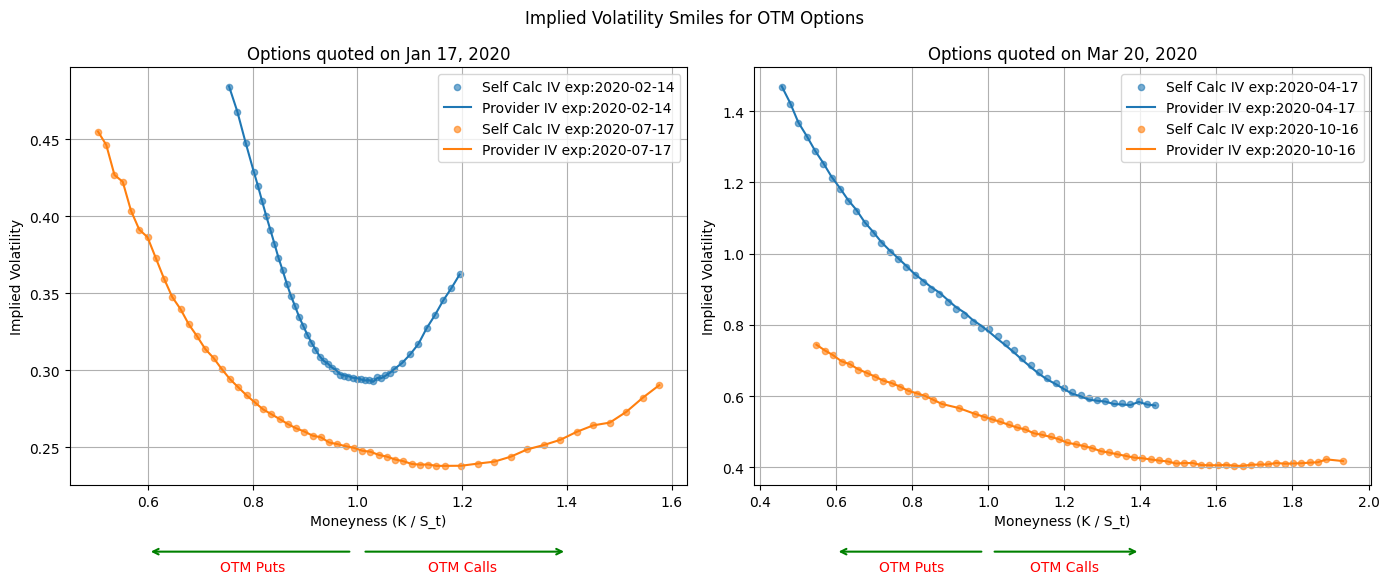

In [7]:
from helpers.BMS import implied_vol_BMS
from helpers.plotting import Q3_plot1 , Q3_plot2
import matplotlib.pyplot as plt
import numpy as np  

# Calculate standard moneyness
options['moneyness'] = options['strike'] / options['stock_exdiv']

# Find ATM implied volatility for each date-expiration pair
# ATM is where moneyness is closest to 1
atm_iv = options.groupby(['date', 'exdate']).apply(
    lambda group: group.loc[(group['moneyness'] - 1).abs().idxmin(), 'implied_vol_bms']
).reset_index(name='atm_iv')

#  Merge ATM IV back to the main dataframe
options = options.merge(atm_iv, on=['date', 'exdate'], how='left')

# Calculate standardized moneyness using ATM IV
options['moneyness_adjusted'] = (
    np.log(options['strike'] / options['stock_exdiv']) / 
    (options['atm_iv'] * np.sqrt(options['YTM']))
)

# filtering for Out-of-the-money options
otm_options_call = options[(options['moneyness'] > 1) & (options['cp_flag'] == 'C')]
otm_options_put = options[(options['moneyness'] <= 1) & (options['cp_flag'] == 'P')]
otm_options = pd.concat((otm_options_call, otm_options_put), axis=0)

# Calculate the implied vol for Out-of-the-money options 
otm_options['self_calc_imp_vol_BMS'] = otm_options.apply(
    lambda row: implied_vol_BMS(row['cp_flag'], row['stock_exdiv'], row['strike'], row['risk_free'], row['YTM'], row['option_price'],"brentq"),
    axis = 1
)

# plotting
fig1=Q3_plot1(otm_options)
plt.tight_layout()
plt.show()



**Discussion:**

**Common Patterns in Both Plots**

- The line plots (provider implied BMS volatility) and scattered dots (our calculated implied BMS volatility) align well, showing correct calculation of implied volatility.
- Both plots show that implied volatility and slope increase as options become more out-of-the-money (except for OTM calls in March, explained later). OTM puts exhibit steeper increases than OTM calls. This occurs because investors are more concerned with market crashes than market rallies, so they seek insurance for crashes more and are willing to pay more for OTM puts than OTM calls, driving up implied volatility for OTM puts.
- Within both plots, for a fixed moneyness, shorter-maturity options have higher volatility levels compared to longer-maturity options. Also, the slope is steeper for shorter-maturity options. This is because near-term options are more sensitive to immediate jump risk and short-term price movements, while longer-dated options average out volatility over time, resulting in smoother smiles.

**Comparing Left and Right Plots**

- The March 20 plot shows dramatically elevated implied volatility levels compared to the January 17 plot. This reflects the COVID-19 market panic (increased uncertainty and risk) in March 2020. The shift from approximately 0.2-0.5 (January) to 0.4-1.5 (March) is consistent with the extreme market conditions during that period.
- In March 2020, OTM call IV declines as moneyness increases (unlike January's symmetric smile), creating a "smirk" pattern, because investors fear sharp market drops far more than they anticipate equally large, fast gains.

<hr style="border: none; border-top: 1px dashed gray;">

**Limitations of Standard Moneyness $M = K/S_t$**

Standard moneyness ignores time to maturity and volatility, making comparisons across different expirations or market regimes (January vs. March 2020) meaningless.

**Better Alternative: Standardized Moneyness**

$$\text{Standardized Moneyness} = \frac{\ln(K/S)}{\sigma\sqrt{\tau}}$$

This measures strike distance in standard deviation units, normalizing for both time $\tau$ and volatility $\sigma$ (ATM implied volatility for each group). It aligns with the BSM framework's $d_1$ and $d_2$ terms and makes volatility smiles comparable across different maturities and volatility regimes (different quote times).

**Impact**: Using standardized moneyness aligns curves from different maturities and reveals whether smile differences reflect genuine tail risk pricing changes or merely time/volatility scaling effects. The plots using standardized moneyness are presented below.


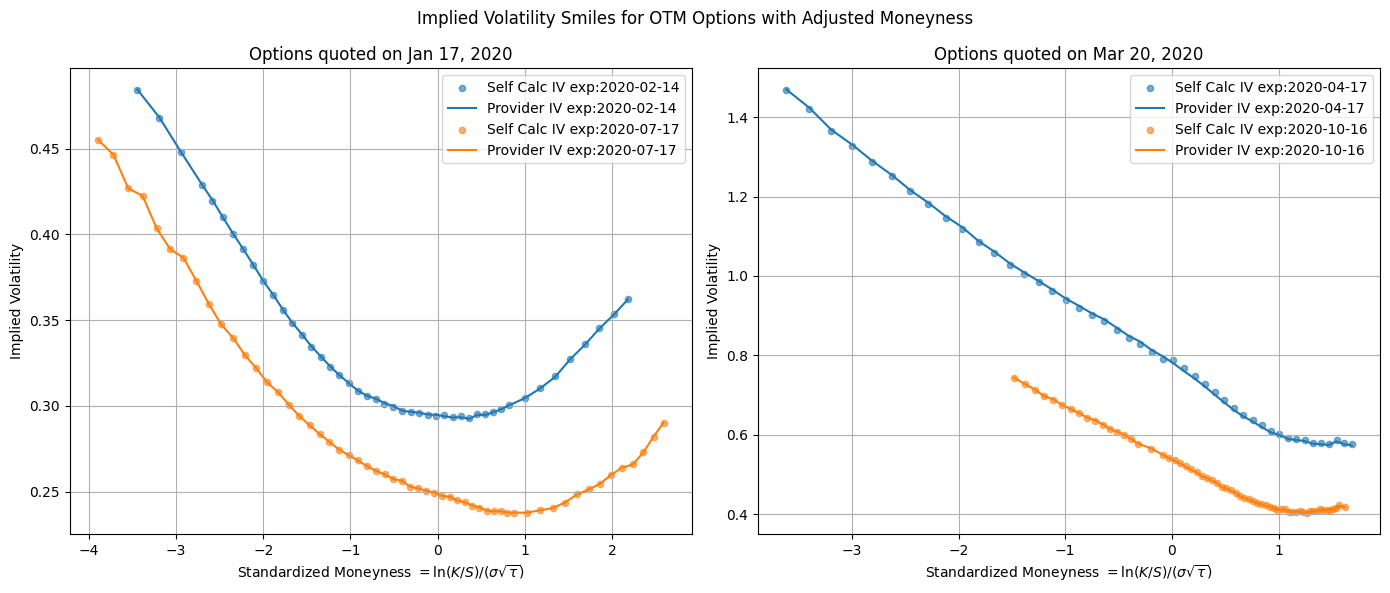

In [8]:
fig2=Q3_plot2(otm_options)
plt.tight_layout()
plt.show()

***
# Question 4

Consider the same OTM options as in the previous question. We now want to scatter
\begin{equation}
    100 \left(\frac{ \text{'impl\_volatility'} }{ \text{'implied\_vol\_bms'} } - 1\right)
\end{equation}
against moneyness (the version you feel most comfortable with). The 'impl_volatility' column provides an implied volatility measure as computed by the data provider using a proprietary algorithm. How should the y-axis be interpreted? Are the magnitudes relatively large or small? Would we obtain the same result comparing CRR and BMS implied volatilities for the in-the-money (ITM) options?

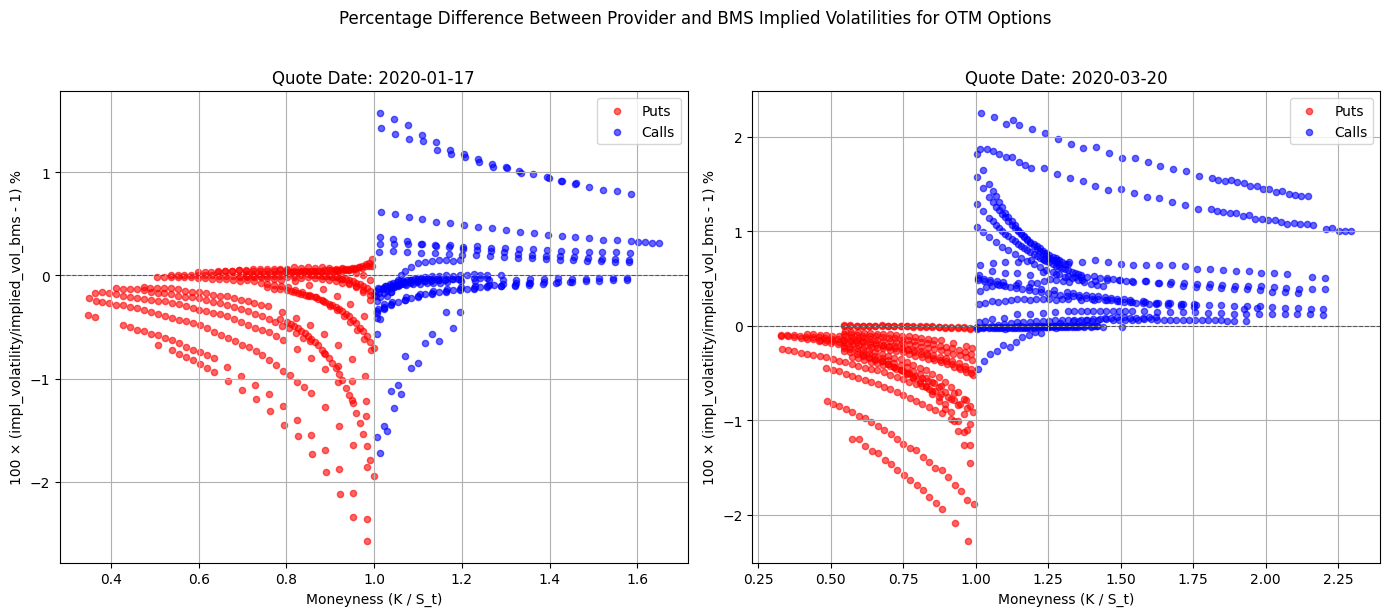

In [9]:
from helpers.plotting import Q3_plot

fig=Q3_plot(otm_options)
plt.tight_layout()
plt.show()

- The y-axis shows the percentage difference between the provider's implied volatility and the BMS model implied volatility; a value of zero means both are equal, positive means provider IV is higher, and negative means provider IV is lower.

- Across both dates, there is a **noticeable but limited discrepancy** between the two volatility measures, suggesting they are generally consistent but not identical.
- For OTM puts (red), provider IVs are consistently lower than BMS IVs (values below zero), especially for deeper OTM strikes; for OTM calls (blue), the provider IVs are higher than BMS IVs, particularly as moneyness increases.

- We would **not obtain same results for ITM options**, since early-exercise value becomes more significant for ITM contracts (CRR considers early exercise value and BMS does not).
Thus, CRR-implied volatilities would deviate more from the European BMS benchmark in those cases.


***
# Question 5

Convert the present value of dividends corresponding to each option into an approximate convenience yield. Implement the CRR tree with diviended yield ($y$) and obtain your own CRR-implied volatility; use a number of time steps equal to 5 times the days to maturity ('DTM').  Compare it with the 'impl_volatility' provided in the dataframe. In particular, does this yield better approximations than the ones in 'implied_vol_bms'? Support your answer with some summary statistics and a figure.

In [10]:
otm_options['convenience_yield'] = (
    -np.log(otm_options['stock_exdiv'] / otm_options['stock_price'])
    / otm_options['YTM']
)

otm_options.loc[:,['stock_price', 'stock_exdiv', 'YTM', 'convenience_yield']]

,stock_price,stock_exdiv,YTM,convenience_yield
27,318.73,318.730000,0.019178,-0.000000
29,318.73,318.730000,0.019178,-0.000000
31,318.73,318.730000,0.019178,-0.000000
33,318.73,318.730000,0.019178,-0.000000
35,318.73,318.730000,0.019178,-0.000000
...,...,...,...,...
2970,229.24,226.093746,2.243836,0.006159
2972,229.24,226.093746,2.243836,0.006159
2974,229.24,226.093746,2.243836,0.006159
2976,229.24,226.093746,2.243836,0.006159


In [11]:
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
from helpers.CRR_tree import Wrapper_implied_vol_crr_fast

# Step 1: Calculate convenience yield for each option
otm_options['convenience_yield'] = (
    -np.log(otm_options['stock_exdiv'] / otm_options['stock_price'])
    / otm_options['YTM']
)


# Step 2: Prepare rows for parallel processing
rows = [row for _, row in otm_options.iterrows()]

# Step 3: Run parallel implied volatility calculation with a progress bar showing progress
results = list(
    tqdm(
        Parallel(n_jobs=-1, prefer="processes", return_as="generator")(
            delayed(Wrapper_implied_vol_crr_fast)(row) for row in rows
        ),
        total=len(rows),
        desc="Calculating implied vol"
    )
)

# Step 4: Store results in the DataFrame
otm_options['crr_implied_vol'] = results


Calculating implied vol: 100%|██████████| 1658/1658 [00:37<00:00, 43.73it/s]


Summary Statistics - Difference Distribution:

BMS Difference (impl_volatility - implied_vol_bms):
count    1658.000000
mean       -0.000072
std         0.003178
min        -0.014417
25%        -0.001409
50%        -0.000103
75%         0.000831
max         0.017484
Name: diff_bms, dtype: float64
MAE (BMS): 0.002073
RMSE (BMS): 0.003178

------------------------------------------------------------

CRR Difference (impl_volatility - crr_implied_vol):
count    1658.000000
mean       -0.000582
std         0.004433
min        -0.021826
25%        -0.003451
50%        -0.000172
75%         0.002479
max         0.010857
Name: diff_crr, dtype: float64
MAE (CRR): 0.003431
RMSE (CRR): 0.004470


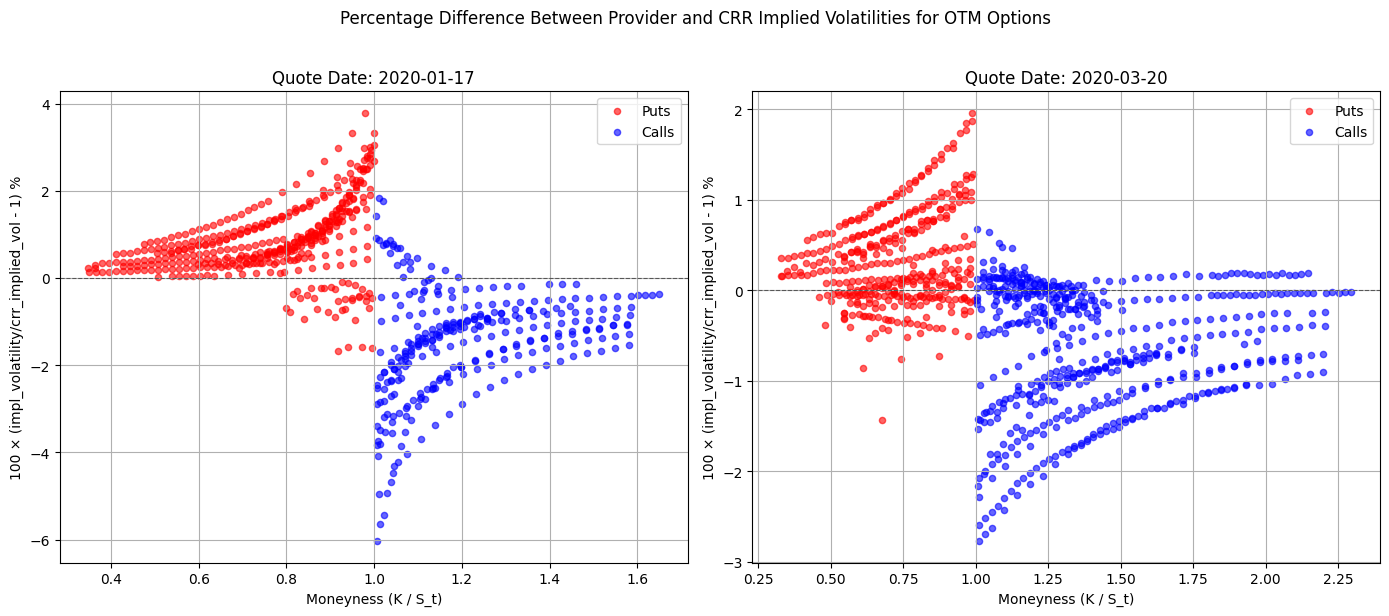

In [12]:
from helpers.plotting import Q4_plot
# Calculate differences between provider's impl_volatility and our estimates
otm_options['diff_bms'] = otm_options['impl_volatility'] - otm_options['implied_vol_bms']
otm_options['diff_crr'] = otm_options['impl_volatility'] - otm_options['crr_implied_vol']

# Summary statistics comparing the differences
print("Summary Statistics - Difference Distribution:")
print("=" * 60)
print("\nBMS Difference (impl_volatility - implied_vol_bms):")
print(otm_options['diff_bms'].describe())
print(f"MAE (BMS): {np.abs(otm_options['diff_bms']).mean():.6f}")
print(f"RMSE (BMS): {np.sqrt((otm_options['diff_bms']**2).mean()):.6f}")

print("\n" + "-" * 60)
print("\nCRR Difference (impl_volatility - crr_implied_vol):")
print(otm_options['diff_crr'].describe())
print(f"MAE (CRR): {np.abs(otm_options['diff_crr']).mean():.6f}")
print(f"RMSE (CRR): {np.sqrt((otm_options['diff_crr']**2).mean()):.6f}")

fig= Q4_plot(otm_options)
plt.tight_layout()
plt.show()

**Discussion**

- The BMS model provides better approximations to the provider's implied volatility compared to the CRR model. The BMS achieves a lower MAE (0.002073 vs 0.003456) and lower RMSE (0.003178 vs 0.004495), with the mean difference also closer to zero (-0.000072 vs -0.000587). The figure confirms this: BMS differences (plotted in question 4) are more tightly clustered around zero across all moneyness levels comapred to the new plot in this question.

- The CRR model's poorer performance stems from the convenience yield approximation used to handle discrete dividends. Converting the present value of dividends into a continuous yield  introduces errors, as this approximation does not accurately capture the discrete nature of Apple's actual dividend payments(which is likely used in providers estimation). Additionally, the finite number of time steps (5×DTM) could be another source of error.
- As shown in the plot, The continuous yield approximation in the CRR model overestimates implied volatilities for calls and underestimates implied volatilities for shorts.

***
# Question 6

Given that the CRR tree should converge to the BMS model, the implied volatility obtained from American options prices using the CRR model can be used in the BMS closed-form formulas to obtain the price at which otherwise identical European options should be traded. Use the approximate convenience yield obtained in the previous question and <span style="background:#ffe6e6;color:#8b0000;padding:2px 4px;border-radius:3px;">the 'impl_volatility' field</span> provided with the data to do so. 

Plot the resulting value of early exercise options. (Hint: Because we are using an approximate convenience yield, some of these values could make little economic sense. Use your economic intuition to impose an upper bound on the artifical European prices.) Discuss the observed patterns.

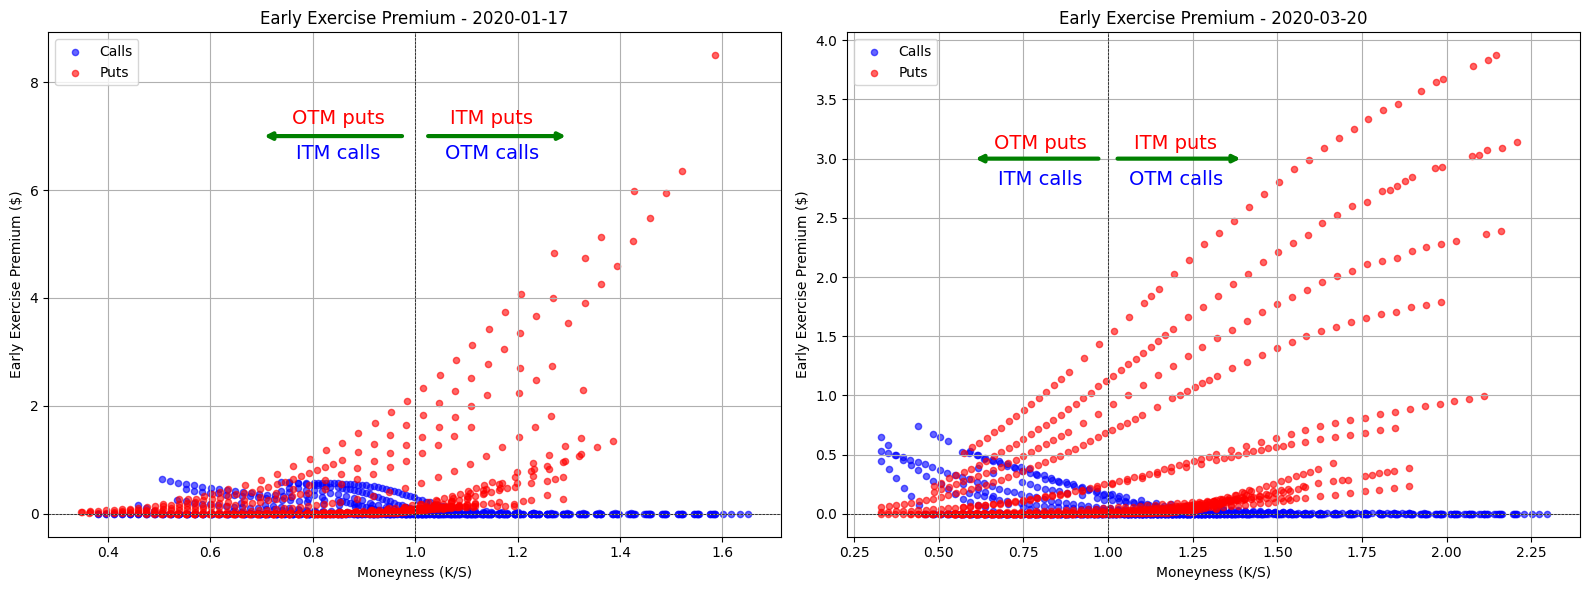

In [13]:
import numpy as np
from helpers.BMS import BMS_with_dividends
import matplotlib.pyplot as plt
import datetime as dt
from helpers.plotting import Q6_plot

# Step 1: Calculate European option prices using BSM with provider IV and convenience yield
options['EU_price_with_AM_IV'] = options.apply(
    lambda row: BMS_with_dividends(
        option_type=row['cp_flag'],
        s_hat=row['stock_exdiv'],
        k= row['strike'],
        r= row['risk_free'],
        ttm= row['YTM'],
        sigma= row['impl_volatility'],  # provider's IV
        ),
    axis=1
)

# Step 2: Apply economic bounds
# European option price cannot exceed American option price
options['european_price_bounded'] = options.apply(
    lambda row: min(row['EU_price_with_AM_IV'], row['option_price']), 
    axis=1
)

# Step 3: Calculate early exercise premium
options['early_exercise_premium'] = options['option_price'] - options['european_price_bounded']

# Step 4: Visualize by date and moneyness
fig=Q6_plot(options)
plt.tight_layout()
plt.show()



**Discussion**

- We enforced the economic bound that a European option price cannot exceed its American counterpart, which addresses negative early exercise premiums that arose due to model mismatch: using a continuous dividend yield with provider IV can overestimate European call option values. These negative premiums are not logically valid, as early exercise flexibility should make American options always worth at least as much as European, so the bound pushes the negative values up to zero.

- Early exercise premiums are largest for deep in-the-money puts. early exercise is valuable for these contracts because holders can lock in profit as cash and earn interest on them, especially when moneyness and interest rates are high.

- Premiums for calls are near zero across moneyness, as early exercise is rarely optimal for calls on dividend-paying stocks (except near ex-dividend dates).

- In the right plot (March 2020), overall early exercise premiums are lower than in January. This is because the surge in volatility during the pandemic increased the value of waiting (optionality), making it less attractive to exercise early. When volatility is high, the potential for large favorable price moves increases, so option holders prefer to keep their options alive rather than lock in a certain but limited payoff by exercising.

***
# Question 7

Muravyev, Pearson and Pollet (2022), suggest that we can use put-call parity to infer borrow fees on stocks. Let $\tilde{h}_t$ be the borrow fee at time $t$. An investor who buy the stock at $S_t$ can lend the stock and receive $\tilde{h}_tS_t$ at time $t+1$.

We can estimate the implied borrow fee from the option prices under Q measure: $\tilde{h}_{t}^{\mathbb{Q}}$. The put-call parity relation including one-day borrow fee is
\begin{equation*}
\hat{S}_t - S_t \left(1 - (1 - e^{-r(T-t)} \tilde{h}_{t}^{\mathbb{Q}})^D \right) = c_t - p_t + e^{-r(T-t)}K
\end{equation*}
where $D$ is the number of days to maturity. Consequently, the one-day borrow fee is:
\begin{equation*}
\tilde{h}_{t}^{\mathbb{Q}} = e^{r(T-t)} \left[1 - \left(1 - \frac{1}{S_t} (\hat{S}_t - c_t + p_t - e^{-r(T-t)} K) \right)^{1/D} \right]
\end{equation*}

Unfortunately, whereas put-call parity applies only to European options, options on individual equities are typically American. However, Muravyev, Pearson and Pollet (2025) suggest that, using a CRR implied volatility for American options, one can use the difference in 1-month ATM implied volatility of puts and calls in to compute an approximation to the 
<span style="background:#ffe6e6;color:#8b0000;padding:2px 4px;border-radius:3px;">annualized borrow fee</span>, which is
\begin{equation*}
h_t^{\mathbb{Q}} \approx -(\sigma_c - \sigma_p) / \sqrt{2\pi (T-t)},
\end{equation*}
Compute this approximation on both dates in the sample and discuss your results.

In [14]:
import numpy as np
import datetime as dt

dates = [dt.date(2020, 1, 17), dt.date(2020, 3, 20)]

for date in dates:
    # 1. Filter for the current date
    options_date = options[options['date'] == date]
    
    # 2. Find expiry closest to 1 month (YTM ~ 1/12)
    expiry_idx = (options_date['YTM'] - 1/12).abs().idxmin()
    expiry = options_date.loc[expiry_idx, 'exdate']
    options_1m = options_date[options_date['exdate'] == expiry]
    
    # 3. Find ATM call (strike closest to stock price)
    stock_price = options_1m['stock_price'].iloc[0]
    calls = options_1m[options_1m['cp_flag'] == 'C']
    call_atm_idx = (calls['strike'] - stock_price).abs().idxmin()
    call_atm_strike = calls.loc[call_atm_idx, 'strike']
    call_iv = calls.loc[call_atm_idx, 'impl_volatility']
    call_ytm = calls.loc[call_atm_idx, 'YTM']
    
    # 4. Find ATM put (strike closest to stock price)
    puts = options_1m[options_1m['cp_flag'] == 'P']
    put_atm_idx = (puts['strike'] - stock_price).abs().idxmin()
    put_atm_strike = puts.loc[put_atm_idx, 'strike']
    put_iv = puts.loc[put_atm_idx, 'impl_volatility']
    put_ytm = puts.loc[put_atm_idx, 'YTM']
    
    # 5. Use average YTM for calculation (should be ideally identical for both)
    ttm = 0.5 * (call_ytm + put_ytm)
    
    # 6. Calculate implied borrow fee
    h_Q = -(call_iv - put_iv) / np.sqrt(2 * np.pi * ttm)
    
    # 7. Print results
    print(f"Date: {date} -> stock_price: {stock_price}")
    print(f"ATM Call Strike: {call_atm_strike}, YTM: {call_ytm:.4f}, IV: {call_iv:.4f}")
    print(f"ATM Put Strike: {put_atm_strike}, YTM: {put_ytm:.4f}, IV: {put_iv:.4f}")
    print(f"Time to maturity (years): {ttm:.4f}")
    print(f"Implied borrow fee (annualized): {h_Q:.4f}\n")



Date: 2020-01-17 -> stock_price: 318.73
ATM Call Strike: 317.5, YTM: 0.0767, IV: 0.2930
ATM Put Strike: 317.5, YTM: 0.0767, IV: 0.2928
Time to maturity (years): 0.0767
Implied borrow fee (annualized): -0.0003

Date: 2020-03-20 -> stock_price: 229.24
ATM Call Strike: 230.0, YTM: 0.0767, IV: 0.7882
ATM Put Strike: 230.0, YTM: 0.0767, IV: 0.7727
Time to maturity (years): 0.0767
Implied borrow fee (annualized): -0.0224



**Discussion**


we obtain the following annualized estimates:

| Date | Stock Price | ATM IV (Call) | ATM IV (Put) | Annualized Borrow Fee |
|------|--------------|---------------|---------------|------------------------|
| 2020-01-17 | 318.73 | 0.2930 | 0.2928 | −0.0003 |
| 2020-03-20 | 229.24 | 0.7882 | 0.7727 | −0.0224 |



- In **January 2020**, call and put implied volatilities are almost identical, leading to an implied borrow fee close to zero. This indicates balanced put-call parity and normal market conditions before the COVID-19 shock.  
- In **March 2020**, both call and put implied volatilities surge sharply, reflecting the extreme market uncertainty during pandemic shock. The gap between put and call IVs generates a larger negative implied borrow fee (around −2.2% annualized).  
- The negative sign implies that put options were relatively more expensive than calls, consistent with investors’ strong demand for downside protection. 
- While both put and call implied volatilities have increased, the gap between them has widened because put IV rose more due to heightened demand for downside protection and increased perceived risk of sharp declines; this leads to a higher implied borrow fee since the cost of shorting is reflected in the elevated put prices in Muravyev, Pearson and Pollet setup.




